**Problem Statement**

This project builds a machine learning model to predict product sale price using product attributes, with the goal of supporting pricing strategy and supply chain planning.

**Business Impact**

* Helps identify pricing patterns across categories.
* Supports inventory planning and demand estimation.
* Enables better pricing decisions based on product features.
* Highlights dependency of sale price on market benchmarks.

**Project Evolution**

Like many real-world machine learning projects, the initial objective evolved during exploratory analysis and model evaluation.

The original goal was to build a predictive model for `sale_price` using product attributes to support pricing and supply chain decisions.

However, during model development, exploratory analysis revealed:
- Data leakage introduced through engineered features
- Strong dominance of `market_price`
- Unrealistically high model performance (R² ≈ 0.99)

These findings required revisiting assumptions and redesigning the experiment to produce more reliable and interpretable results.

**Refined Objective**

Rather than focusing only on prediction accuracy, this project evolved to investigate:

- The impact of feature leakage on model performance
- The influence of dominant predictors such as `market_price`
- Which product attributes truly contribute to pricing behavior

Three Random Forest models were developed and compared:

1. Model 1: Initial model with engineered features
2. Model 2: Leakage features removed
3. Model 3: Leakage features and `market_price` removed

**Import Libraries**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

**Load Data**

In [80]:
df=pd.read_csv('/content/sales-data.csv')
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


**Exploratory Data Analysis**

In [81]:
df.shape

(27555, 10)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,27555.0,13778.000000,7954.587670,1.00,6889.5,13778.0,20666.5,27555.0
sale_price,27555.0,322.514808,486.263116,2.45,95.0,190.0,359.0,12500.0
market_price,27555.0,382.056664,581.730717,3.00,100.0,220.0,425.0,12500.0
rating,18929.0,3.943410,0.739063,1.00,3.7,4.1,4.3,5.0


In [84]:
df.tail()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori..."
27554,27555,United Dreams Go Far Deodorant,Beauty & Hygiene,Men's Grooming,United Colors Of Benetton,214.53,390.0,Men's Deodorants,4.5,The new mens fragrance from the United Dreams ...


In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.isnull().sum()

,0
index,0
product,1
category,0
sub_category,0
brand,1
sale_price,0
market_price,0
type,0
rating,8626
description,115


In [87]:
df.isnull().sum()/df.shape[0]*100

,0
index,0.000000
product,0.003629
category,0.000000
sub_category,0.000000
brand,0.003629
sale_price,0.000000
market_price,0.000000
type,0.000000
rating,31.304663
description,0.417347


In [88]:
# drop unnnecessary columns
df=df.drop(['index','description'], axis=1)

In [89]:
df['rating'].skew()

np.float64(-1.7308012163378228)

In [90]:
df['rating'].describe()

,rating
count,18929.000000
mean,3.943410
std,0.739063
min,1.000000
25%,3.700000
50%,4.100000
75%,4.300000
max,5.000000


<Axes: >

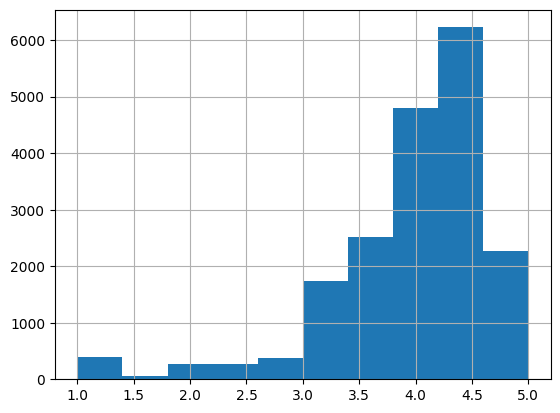

In [91]:
df['rating'].hist()

In [92]:
df.groupby('category')['rating'].median()

,rating
category,
Baby Care,4.2
"Bakery, Cakes & Dairy",4.0
Beauty & Hygiene,4.1
Beverages,4.2
Cleaning & Household,4.1
"Eggs, Meat & Fish",NaN
"Foodgrains, Oil & Masala",4.1
Fruits & Vegetables,NaN
Gourmet & World Food,4.1


In [93]:
# Fill missing values
df['product']=df['product'].fillna('Unknown')
df['brand']=df['brand'].fillna('Unknown')
df['rating']=df.groupby('category')['rating'].transform(lambda x: x.fillna(x.median()))

In [94]:
df['rating'].fillna(df['rating'].median(), inplace=True)

/tmp/ipykernel_1430/333645285.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)


**Insights**

The rating feature contains approximately 31% missing values, making it a critical column requiring careful imputation.

Statistical summary shows:

Mean = 3.94

Median = 4.10

Skewness = -1.74, indicating a left-skewed distribution

Histogram confirms that most ratings are concentrated between 4.0 and 4.5, with a smaller number of low ratings pulling the mean downward.

Interpretation:

The mean is biased downward due to a few low-rating outliers.

The median better represents the typical customer rating behavior.

Imputation Decision:

To preserve realistic rating patterns and aviod distortion from outliers:

Missing values were filled using median rating grouped by product category (category-level median). This accounts for category-specific rating behavior, maintains robustness against skewness and outliers, and prevents introducing bias that would occur with mean imputation.

Edge case:

Two categories with NAN were filled with global median.

product and brand missing values are approximately 0.0036% each, almost zero.

Therefore, both missing values were imputed with 'unknown' values.



In [95]:
df.isnull().sum()

,0
product,0
category,0
sub_category,0
brand,0
sale_price,0
market_price,0
type,0
rating,0


In [96]:
df.groupby('category')['rating'].median()

,rating
category,
Baby Care,4.2
"Bakery, Cakes & Dairy",4.0
Beauty & Hygiene,4.1
Beverages,4.2
Cleaning & Household,4.1
"Eggs, Meat & Fish",4.1
"Foodgrains, Oil & Masala",4.1
Fruits & Vegetables,4.1
Gourmet & World Food,4.1


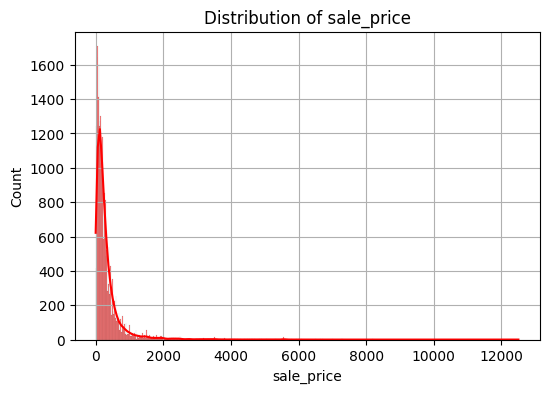

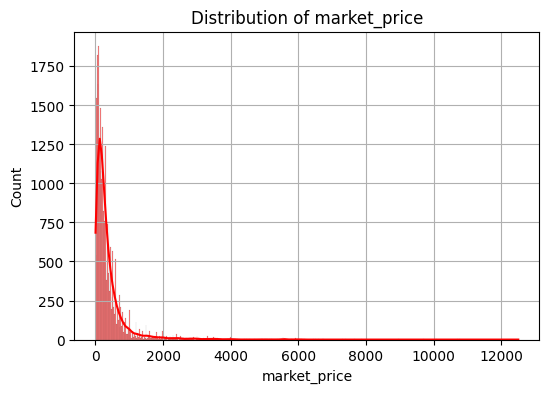

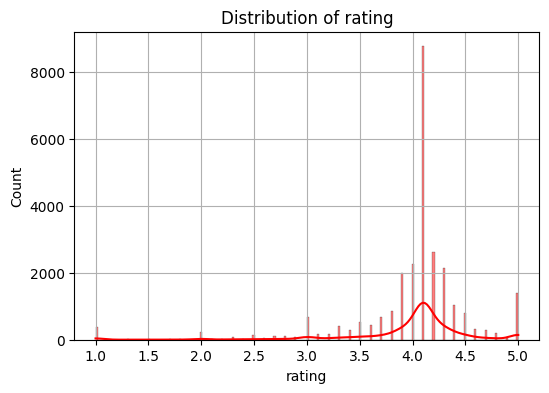

In [97]:
# distribution on numerical columns
num_cols=df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True, color='red')
  plt.title(f"Distribution of {col}")
  plt.grid(True)
  plt.show()

**Insights:**

***sale_price distribution* shows it is right-skewed (positive skew). Most values concentrated below ~1000, and long tail extending up to ~12000+

The majority of products are low to moderately priced, with small number of high-priced outliers significantly extending the upper range.

**Implication:**

1. Mean will be inflated by expensive products.

2. Median is a better central measure.

3. Potential need for Log transformation, outlier handling/ outlier-robust model

***market_price distribution* follow a similar distribution to sale_price, indicating that priceing across products is generallly low with a few premium-priced items.

**Implication:**

Confirms dataset pricing structure is non-normal.

Suggesting:

1. Pricing strategies vary widely across products.

2. Outliers likely represent premium/luxury items.

***rating distribution* shows left-skewed as noted earlier. strong concentration around 4.0-4.5 and very few low ratings(1-2).

Product ratings are heavily concentrated in the higher range, indicating positive customer feedback, very few low rated products.


**Conclusion**

While product prices very widely with significant high-value outliers, customer ratings remain consistently high, suggesting that even higher-priced itmes do not negatively impact customer satisfaction.

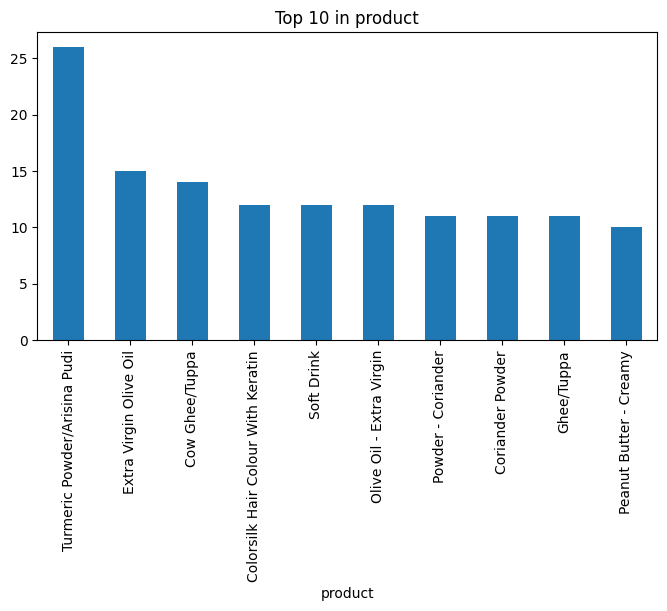

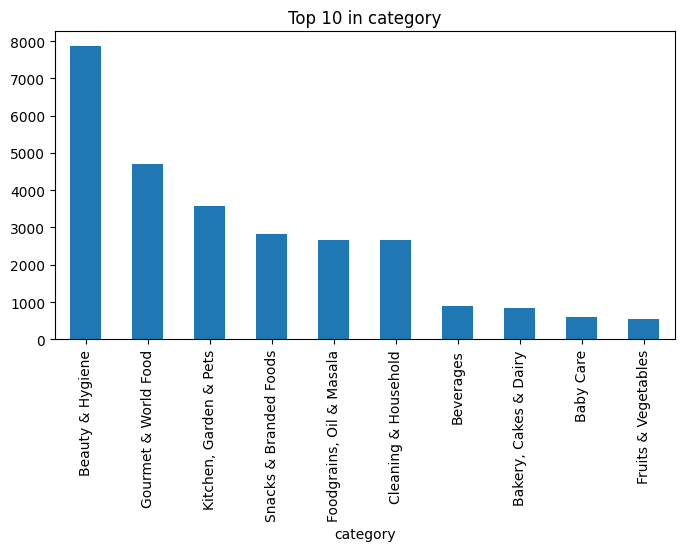

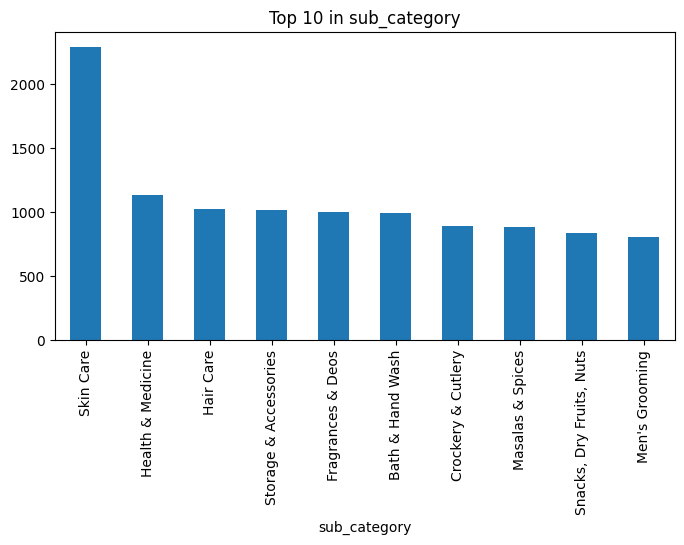

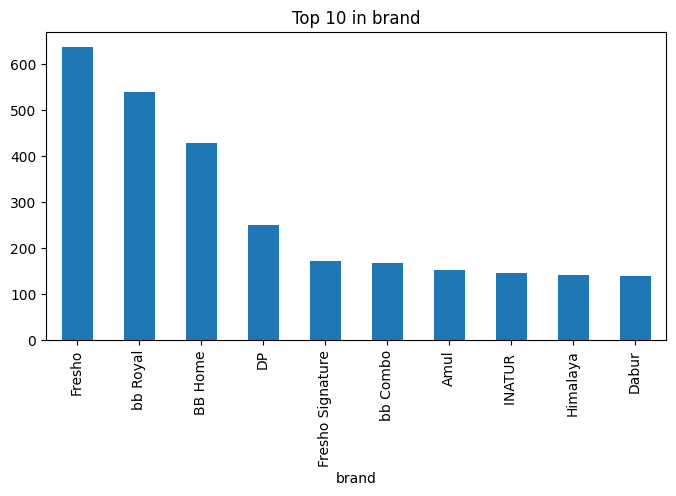

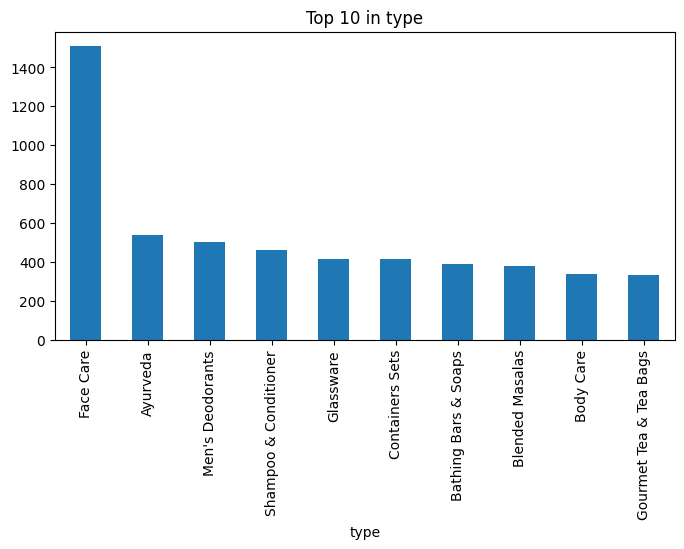

In [98]:
# top 10 products for categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
  plt.figure(figsize=(8,4))
  df[col].value_counts().head(10).plot(kind='bar')
  plt.title(f'Top 10 in {col}')
  plt.xticks(rotation=90)
  plt.show()

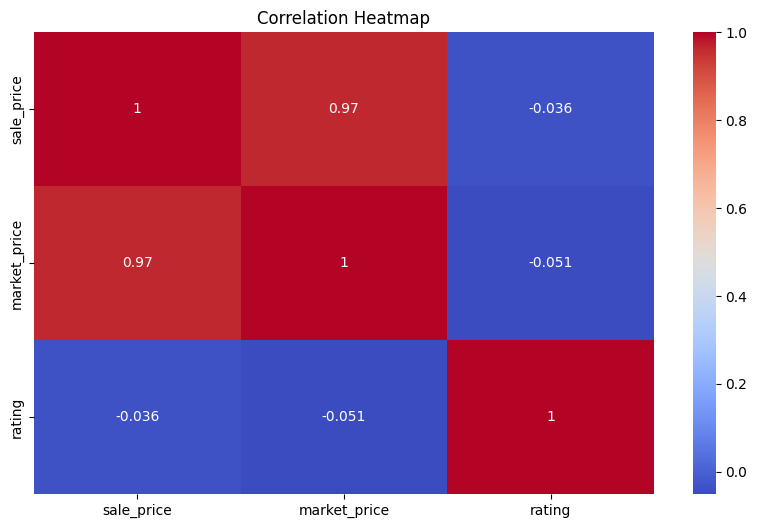

In [99]:
# correlation heatmap for numeric columns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

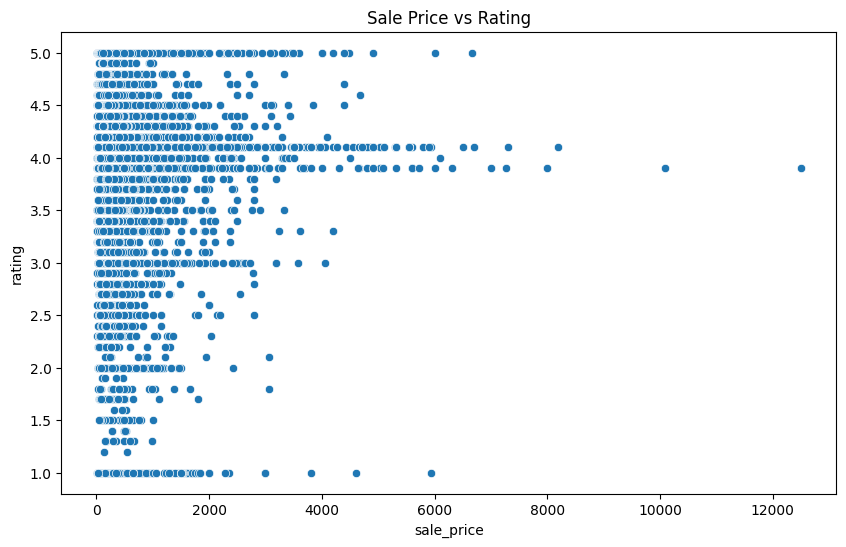

In [100]:
# relationship analysis
plt.figure(figsize=(10,6))
sns.scatterplot(x='sale_price', y='rating', data=df)
plt.title('Sale Price vs Rating')
plt.show()

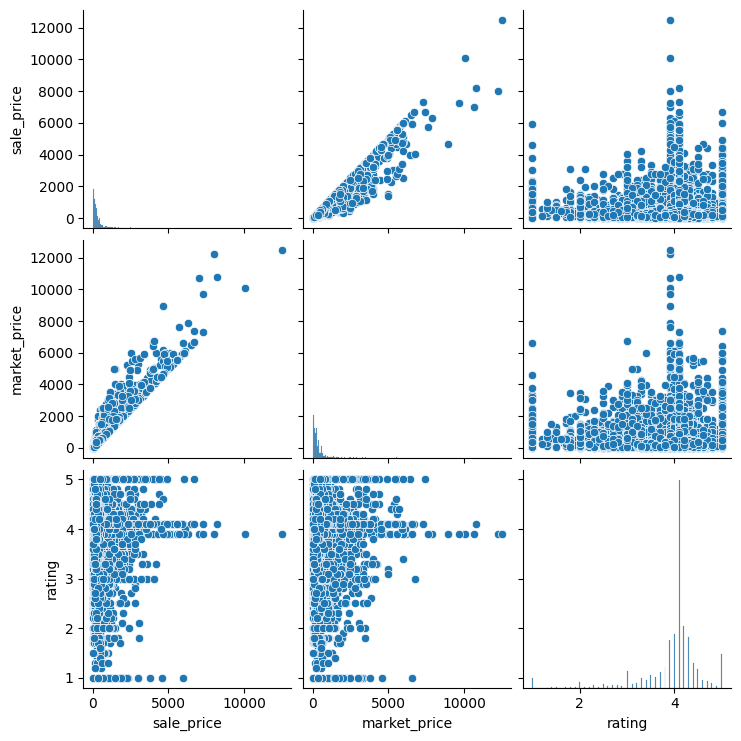

In [101]:
#
sns.pairplot(df[num_cols].dropna())
plt.show()

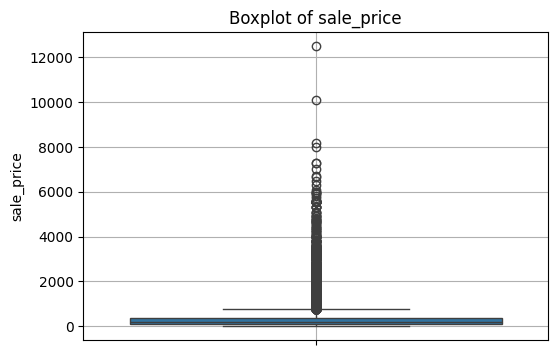

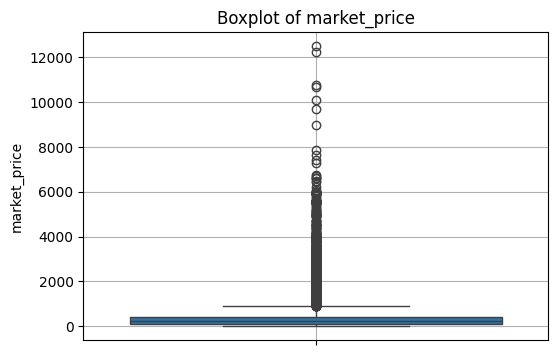

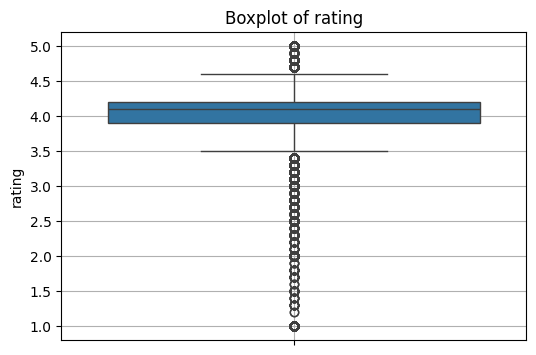

In [102]:
# outliers analysis
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")
  plt.grid(True)
  plt.show()

**Insights:**

As shown above, the dataset contains some outliers as discussed earlier, which will be retained.

Since tree-based models like Random Firest are robust to outliers, I chose to retain them while still analyzing their distribution to understand data behavior.





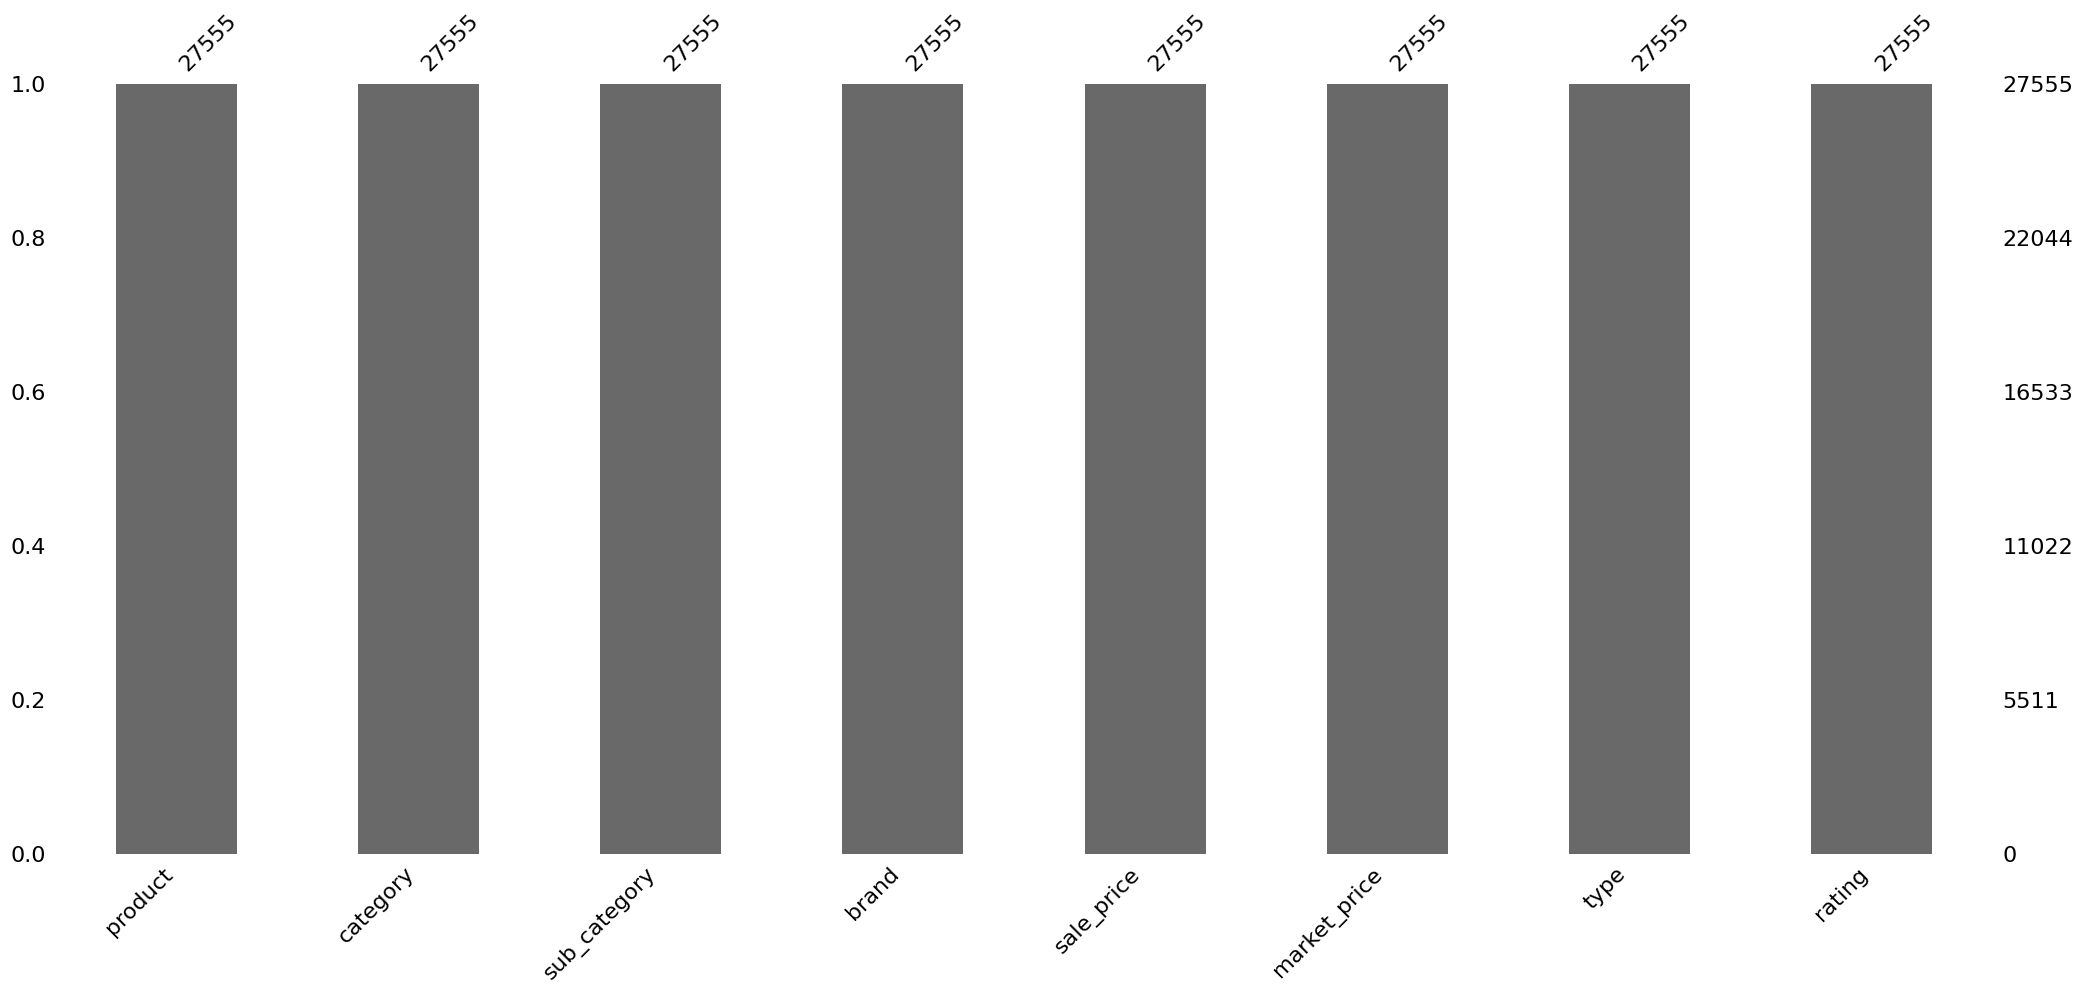

In [103]:
# accessing dataset completeness
plt.figure(figsize=(6,3))
msno.bar(df)
plt.show()

**Data Preprocessing**

In [104]:
# label encoding
le=LabelEncoder()

cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
  df[col]=le.fit_transform(df[col])


In [105]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating
0,8277,2,49,1959,220.0,220.0,204,4.1
1,22936,9,86,1258,180.0,180.0,420,2.3
2,2957,4,73,2125,119.0,250.0,249,3.4
3,3573,4,9,1386,149.0,176.0,250,3.7
4,5476,2,8,1455,162.0,162.0,39,4.4


**Feature Engineering**

**Initial Feature Engineering Experiment**

Initial experimentation included creating pricing-derived features:

- discount
- discount_pct

These variables were created to explore pricing behavior.

During model evaluation, these engineered variables were identified as sources of target leakage because they directly used `sale_price`, the prediction target.

To preserve model validity, subsequent experiments removed these features and rebuilt the models.

In [106]:
df['discount'] = df['market_price'] - df['sale_price']
df['discount_pct'] = df['discount']/df['market_price']

In [107]:
df['discount_pct']

,discount_pct
0,0.000000
1,0.000000
2,0.524000
3,0.153409
4,0.000000
...,...
27550,0.200000
27551,0.100000
27552,0.000000
27553,0.200000


In [108]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating,discount,discount_pct
0,8277,2,49,1959,220.0,220.0,204,4.1,0.0,0.000000
1,22936,9,86,1258,180.0,180.0,420,2.3,0.0,0.000000
2,2957,4,73,2125,119.0,250.0,249,3.4,131.0,0.524000
3,3573,4,9,1386,149.0,176.0,250,3.7,27.0,0.153409
4,5476,2,8,1455,162.0,162.0,39,4.4,0.0,0.000000


In [109]:
# train-test-split
X = df.drop('sale_price', axis=1)
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [110]:
X_train

,product,category,sub_category,brand,market_price,type,rating,discount,discount_pct
6790,23299,2,41,61,2100.0,137,1.0,630.00,0.300000
6705,5021,2,49,1747,1004.0,368,4.1,0.00,0.000000
2392,6028,9,21,1657,1320.0,240,3.9,200.00,0.151515
11940,12363,2,80,1559,475.0,47,1.0,0.00,0.000000
4373,15205,6,68,1287,105.0,307,3.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...
21575,20251,8,82,1478,375.0,132,4.1,0.00,0.000000
5390,8044,10,45,693,70.0,176,3.6,14.00,0.200000
860,6984,10,17,2101,700.0,85,3.8,0.00,0.000000
15795,15682,8,16,819,125.0,99,4.1,0.00,0.000000


In [111]:
X_test

,product,category,sub_category,brand,market_price,type,rating,discount,discount_pct
16201,11248,8,16,1877,168.0,99,2.0,55.44,0.330000
24962,20607,0,28,1236,399.0,124,4.2,71.00,0.177945
18964,4978,2,49,2258,500.0,368,2.0,0.00,0.000000
8880,20505,9,85,2057,995.0,258,4.1,166.00,0.166834
13852,13332,2,50,1368,120.0,11,4.1,0.00,0.000000
...,...,...,...,...,...,...,...,...,...
12042,7071,2,80,139,500.0,8,5.0,125.00,0.250000
6203,1987,7,43,741,15.0,252,4.1,3.00,0.200000
817,16543,4,9,1716,307.0,57,4.4,0.00,0.000000
11235,20416,9,22,1422,350.0,117,4.0,121.00,0.345714


In [112]:
y_train

,sale_price
6790,1470.00
6705,1004.00
2392,1120.00
11940,475.00
4373,105.00
...,...
21575,375.00
5390,56.00
860,700.00
15795,125.00


In [113]:
y_test

,sale_price
16201,112.56
24962,328.00
18964,500.00
8880,829.00
13852,120.00
...,...
12042,375.00
6203,12.00
817,307.00
11235,229.00


**Model Building**

In [114]:
# base model
rf = RandomForestRegressor(random_state=42)

In [115]:
#hyperparameter grid
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [116]:
# grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [117]:
# fit
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [118]:
# check best parameters
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_)

Best Parameters:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:  0.9799828806237194


In [119]:
# best model
best_rf= grid_search.best_estimator_

In [120]:
# predict on test data
y_pred=best_rf.predict(X_test)
y_pred

array([110.51584485, 331.82030644, 502.55402793, ..., 302.62967189,
       228.7705    , 136.78664712])

In [121]:
# evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 8.534881036977062
RMSE: 44.86949604129485
R2: 0.9906652626247026


**Result Insights**

An R2 score of 0.9907 means that the model explains approximately 99.07% of the variance in sale_price. The low MAE and RMSE values further confirm that the model is making highly accurate predictions with relatively small average errors.

**Metrics Evaluated**

*MAE* measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute difference between predictions and actual observations. Therefore a lower MAE indicates a more accurate model.

*RMSE* measures the square root of the average difference between predictions and actual observation. RMSE gives a relatively high weight to large errors, that is, it is more sensitive to outliers tham MAE. However, a lower RMSE indicates a more accurate model.


*R2 score* it indicates how well the model's predictions align with the actual values. Generally, higher R2 values are better.

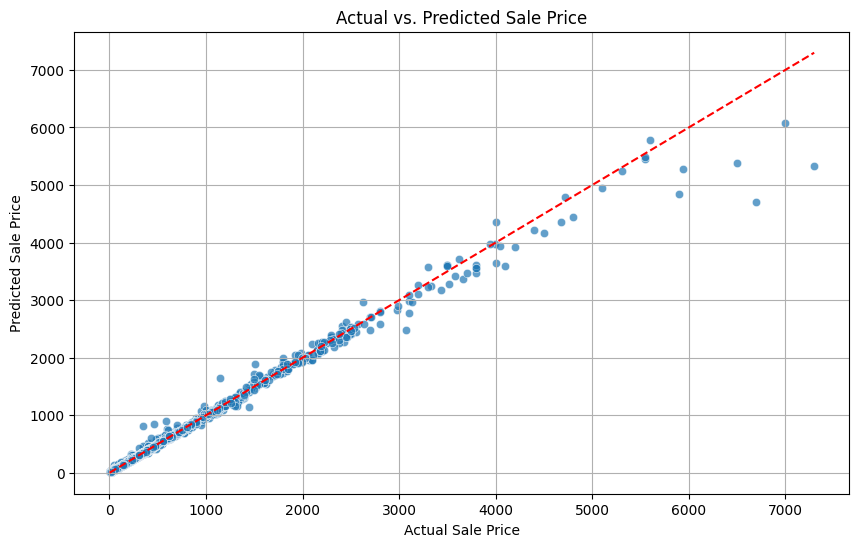

In [122]:
# actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs. Predicted Sale Price')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # diagonal line for perfect prediction
plt.grid(True)
plt.show()

**Insights:**

The scatter plot above shows how closely predicted values align with actual sale prices.

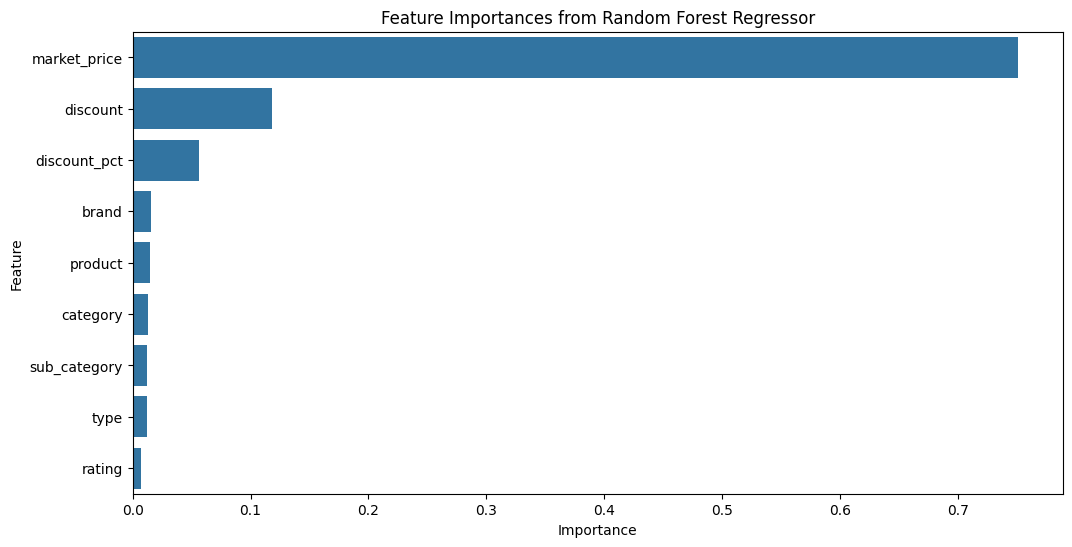

,Feature,Importance
4,market_price,0.751481
7,discount,0.117967
8,discount_pct,0.056050
3,brand,0.015525
0,product,0.014309
1,category,0.013381
2,sub_category,0.012385
5,type,0.011786
6,rating,0.007117


In [123]:
# identify top features influencing the predictions
feature_importances = best_rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

display(importance_df)

**Insight:**

market_price is a dominant feature, confirming pricing dependency on market benchmarks.

In [124]:
# check for potential overfitting by comparing train and test performance
# Predict on training data
y_train_pred = best_rf.predict(X_train)

# Evaluate training performance
print("--- Training Set Metrics ---")
print("MAE (Train):", mean_absolute_error(y_train, y_train_pred))
print("RMSE (Train):", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2 (Train):", r2_score(y_train, y_train_pred))

print("\n--- Test Set Metrics ---")
print("MAE (Test):", mean_absolute_error(y_test, y_pred))
print("RMSE (Test):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 (Test):", r2_score(y_test, y_pred))

--- Training Set Metrics ---
MAE (Train): 4.207619185385314
RMSE (Train): 27.292538091152505
R2 (Train): 0.9969637853956225

--- Test Set Metrics ---
MAE (Test): 8.534881036977062
RMSE (Test): 44.86949604129485
R2 (Test): 0.9906652626247026


**Insights:**

Overfitting occurs when a model learns the training data too well, capturing noise and specific details that don't generalize to new data. Severe overfitting is usually identified if there's a significant drop in performance from the training set to the test set.

In this model:


* R2 Score: The R2 on the training set is 0.9970, and the test set, it's 0.9907. While there's a drop, and R2 of 0.9907 on unseen data is still exceptionally high, indicating that the model explains over 99% of the variance in sale_price on new data.

* MAE and RMSE: Similarly, while MAE nd RMSE are higher on the test set, they are still relatively low in absolute terms, especially considering the range of the sale_price values.


**Conclusion:**

While there's slight difference, which is normal, the performance on the test set remains very strong. This suggests that the model is generalizing exceptionally well and is not severely overfitting the training data. The model has learned robust patterns rather than just memorizing the training examples.



1. Because the R2 score is almost perfect and the model is not overfitting to the test above.

I suspect a data leakage  problem from  the engineered features (discount & discount_pct).

sale_price  = market_price - discount

This could mean model is indirectly learning from sale_price (target feature) and the R2 score is not real performance.

2. Based on feature importance analysis, market_price (0.75148) is a dominant feature.

**Conclusion:**

1. I will build a second model without leakage features

2. A third model without leakage and dominant features

3. Then compared performance of the 3 models, for any unrealistic model performance.


**Model_2:**

Rebuild model after removing leakage features.

In [125]:
df

,product,category,sub_category,brand,sale_price,market_price,type,rating,discount,discount_pct
0,8277,2,49,1959,220.00,220.0,204,4.1,0.00,0.000000
1,22936,9,86,1258,180.00,180.0,420,2.3,0.00,0.000000
2,2957,4,73,2125,119.00,250.0,249,3.4,131.00,0.524000
3,3573,4,9,1386,149.00,176.0,250,3.7,27.00,0.153409
4,5476,2,8,1455,162.00,162.0,39,4.4,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...
27550,23384,2,41,1145,199.20,249.0,329,3.9,49.80,0.200000
27551,18608,8,20,1672,67.50,75.0,215,4.0,7.50,0.100000
27552,16244,8,82,675,200.00,200.0,286,3.8,0.00,0.000000
27553,9120,3,87,2062,396.00,495.0,395,4.2,99.00,0.200000


**Encoding Strategy Update**

Initial experimentation used Label Encoding for categorical variables. However, Label Encoding can unintentionally introduce ordinal relationships among categories (e.g., Category A < Category B), which may not reflect reality.

To avoid introducing artificial hierarchy, the final modeling approach uses One-Hot Encoding (`pd.get_dummies()`), which creates independent binary features for categorical variables.

In [126]:
# one-hot encoding

pd.get_dummies(df, drop_first=True)

,product,category,sub_category,brand,sale_price,market_price,type,rating,discount,discount_pct
0,8277,2,49,1959,220.00,220.0,204,4.1,0.00,0.000000
1,22936,9,86,1258,180.00,180.0,420,2.3,0.00,0.000000
2,2957,4,73,2125,119.00,250.0,249,3.4,131.00,0.524000
3,3573,4,9,1386,149.00,176.0,250,3.7,27.00,0.153409
4,5476,2,8,1455,162.00,162.0,39,4.4,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...
27550,23384,2,41,1145,199.20,249.0,329,3.9,49.80,0.200000
27551,18608,8,20,1672,67.50,75.0,215,4.0,7.50,0.100000
27552,16244,8,82,675,200.00,200.0,286,3.8,0.00,0.000000
27553,9120,3,87,2062,396.00,495.0,395,4.2,99.00,0.200000


This aviods introducing artificial ordinal relationships among categorical variables

In [127]:
# remove discount & discount_pct

df.drop(['discount', 'discount_pct'], axis=1, inplace=True)

In [128]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating
0,8277,2,49,1959,220.0,220.0,204,4.1
1,22936,9,86,1258,180.0,180.0,420,2.3
2,2957,4,73,2125,119.0,250.0,249,3.4
3,3573,4,9,1386,149.0,176.0,250,3.7
4,5476,2,8,1455,162.0,162.0,39,4.4


In [129]:
# split train test

X = df.drop('sale_price', axis=1)
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [130]:
X_train.head()

,product,category,sub_category,brand,market_price,type,rating
6790,23299,2,41,61,2100.0,137,1.0
6705,5021,2,49,1747,1004.0,368,4.1
2392,6028,9,21,1657,1320.0,240,3.9
11940,12363,2,80,1559,475.0,47,1.0
4373,15205,6,68,1287,105.0,307,3.0


In [131]:
y_train.head()

,sale_price
6790,1470.0
6705,1004.0
2392,1120.0
11940,475.0
4373,105.0


In [132]:
# base model_2

rf2 = RandomForestRegressor(random_state=42)

In [133]:
# grid search
grid_search = GridSearchCV(
    estimator=rf2,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [134]:
# fit
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [135]:
# check best parameters

print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_)

Best Parameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:  0.9444377175169872


In [136]:
# best model

best_rf2= grid_search.best_estimator_

In [137]:
# predict on test data

y_pred2=best_rf2.predict(X_test)
y_pred2

array([149.9065, 362.2866, 441.0804, ..., 261.4794, 271.553 , 140.4   ])

In [138]:
# evaluate

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))
print("R2:", r2_score(y_test, y_pred2))

MAE: 37.147124557189514
RMSE: 104.67786643562549
R2: 0.9491946503137481


**Model_3:**

Build model_3 without the leakage feautures and market_price

In [139]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating
0,8277,2,49,1959,220.0,220.0,204,4.1
1,22936,9,86,1258,180.0,180.0,420,2.3
2,2957,4,73,2125,119.0,250.0,249,3.4
3,3573,4,9,1386,149.0,176.0,250,3.7
4,5476,2,8,1455,162.0,162.0,39,4.4


In [140]:
# remove market_price

df.drop("market_price", axis=1, inplace=True)

In [141]:
# train test split

X = df.drop('sale_price', axis=1)
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [142]:
X_train.head()

,product,category,sub_category,brand,type,rating
6790,23299,2,41,61,137,1.0
6705,5021,2,49,1747,368,4.1
2392,6028,9,21,1657,240,3.9
11940,12363,2,80,1559,47,1.0
4373,15205,6,68,1287,307,3.0


In [143]:
X_test.head()

,product,category,sub_category,brand,type,rating
16201,11248,8,16,1877,99,2.0
24962,20607,0,28,1236,124,4.2
18964,4978,2,49,2258,368,2.0
8880,20505,9,85,2057,258,4.1
13852,13332,2,50,1368,11,4.1


In [144]:
y_train.head()

,sale_price
6790,1470.0
6705,1004.0
2392,1120.0
11940,475.0
4373,105.0


In [145]:
# base model_3

rf3 = RandomForestRegressor(random_state=42)

In [146]:
# grid search
grid_search = GridSearchCV(
    estimator=rf3,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [147]:
# fit
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [148]:
# check best parameters

print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_)

Best Parameters:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score:  0.4725528425838791


In [149]:
# best model

best_rf3= grid_search.best_estimator_

In [150]:
# predict on test data

y_pred3=best_rf3.predict(X_test)
y_pred3

array([197.94347926, 750.8636649 , 429.70300106, ..., 118.15534685,
       303.2860206 , 141.0694375 ])

In [151]:
# evaluate

print("MAE:", mean_absolute_error(y_test, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))
print("R2:", r2_score(y_test, y_pred3))

MAE: 158.83876675183947
RMSE: 332.3736679151153
R2: 0.48778423615708966


In [152]:
# compare the 3 model's evaluations.

comparison = pd.DataFrame({
    'Model': ['Model_1', 'Model_2', 'Model_3'],
    'MAE': [8.53, 37.15, 158.84],
    'RMSE': [44.87, 104.68, 332.37],
    'R2': [0.9907, 0.9492, 0.4878]
})

comparison.style.background_gradient(cmap='Blues')

,Model,MAE,RMSE,R2
0,Model_1,8.530000,44.870000,0.990700
1,Model_2,37.150000,104.680000,0.949200
2,Model_3,158.840000,332.370000,0.487800


**Key Findings**

Model comparison revealed important insights:

- Initial near-perfect performance was heavily influenced by leakage and dominant features.
- Removing leakage produced a more realistic and trustworthy model.
- Removing `market_price` caused substantial performance decline, showing its importance as a pricing driver.
- Product attributes contribute to pricing, but market benchmarks remain the strongest influence.

This demonstrates how machine learning projects often shift from pure prediction toward understanding feature behavior and model reliability.

**Final Conclusion**

This project initially focused on predicting sale_price using product attributes. During experimentation, model performance revealed leakage and dominant feature influence issues.

Three Random Forest models were developed and compared:

- Model_1 included leakage variables
- Model_2 removed leakage variables
- Model_3 removed leakage variables and market_price

Results showed that market_price is the strongest predictor of sale_price, while product attributes alone provide moderate predictive power.

This project highlights the importance of feature validation, leakage detection, and iterative model refinement in real-world machine learning workflows.